In [1]:
import pandas as pd

df = pd.read_csv("../dataset/movies.csv")

print(df.head())

ModuleNotFoundError: No module named 'pandas'

In [2]:
import pandas as pd
df =pd.read_csv("../dataset/movies.csv")
print(df.head)

<bound method NDFrame.head of      Rank                    Title                     Genre  \
0       1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1       2               Prometheus  Adventure,Mystery,Sci-Fi   
2       3                    Split           Horror,Thriller   
3       4                     Sing   Animation,Comedy,Family   
4       5            Suicide Squad  Action,Adventure,Fantasy   
..    ...                      ...                       ...   
995   996     Secret in Their Eyes       Crime,Drama,Mystery   
996   997          Hostel: Part II                    Horror   
997   998   Step Up 2: The Streets       Drama,Music,Romance   
998   999             Search Party          Adventure,Comedy   
999  1000               Nine Lives     Comedy,Family,Fantasy   

                                           Description              Director  \
0    A group of intergalactic criminals are forced ...            James Gunn   
1    Following clues to the origin of man

In [3]:
print(df.columns.tolist())

['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


In [5]:
import pandas as pd
df = pd.read_csv("../dataset/movies.csv")
print(df.head())

   Rank                    Title                     Genre  \
0     1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1     2               Prometheus  Adventure,Mystery,Sci-Fi   
2     3                    Split           Horror,Thriller   
3     4                     Sing   Animation,Comedy,Family   
4     5            Suicide Squad  Action,Adventure,Fantasy   

                                         Description              Director  \
0  A group of intergalactic criminals are forced ...            James Gunn   
1  Following clues to the origin of mankind, a te...          Ridley Scott   
2  Three girls are kidnapped by a man with a diag...    M. Night Shyamalan   
3  In a city of humanoid animals, a hustling thea...  Christophe Lourdelet   
4  A secret government agency recruits some of th...            David Ayer   

                                              Actors  Year  Runtime (Minutes)  \
0  Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...  2014                121

In [7]:
print(df.columns.tolist())

['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   str    
 2   Genre               1000 non-null   str    
 3   Description         1000 non-null   str    
 4   Director            1000 non-null   str    
 5   Actors              1000 non-null   str    
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 93.9 KB
None


In [9]:
print(df.isnull().sum())

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64


In [10]:
data=df[['Genre','Year','Runtime(Minutes)','Votes','Revanue (Millions)','Metascore','Rating']].copy()
print(data.head())

KeyError: "['Runtime(Minutes)', 'Revanue (Millions)'] not in index"

In [11]:
data=df[['Genre','Year','Runtime','Votes','Revanue','Metascore','Rating']].copy()
print(data.head())

KeyError: "['Runtime', 'Revanue'] not in index"

In [12]:
data=df[['Genre','Year','Runtime (Minutes)','Votes','Revenue (Millions)','Metascore','Rating']].copy()
print(data.head())

                      Genre  Year  Runtime (Minutes)   Votes  \
0   Action,Adventure,Sci-Fi  2014                121  757074   
1  Adventure,Mystery,Sci-Fi  2012                124  485820   
2           Horror,Thriller  2016                117  157606   
3   Animation,Comedy,Family  2016                108   60545   
4  Action,Adventure,Fantasy  2016                123  393727   

   Revenue (Millions)  Metascore  Rating  
0              333.13       76.0     8.1  
1              126.46       65.0     7.0  
2              138.12       62.0     7.3  
3              270.32       59.0     7.2  
4              325.02       40.0     6.2  


In [13]:
data['Revenue (Millions)'] = data['Revenue (Millions)'].fillna(
    data['Revenue (Millions)'].median()
)

data['Metascore'] = data['Metascore'].fillna(
    data['Metascore'].median()
)

print(data.isnull().sum())

Genre                 0
Year                  0
Runtime (Minutes)     0
Votes                 0
Revenue (Millions)    0
Metascore             0
Rating                0
dtype: int64


In [16]:
from sklearn.preprocessing import MultiLabelBinarizer

#split multiple genres
genres =data['Genre'].str.split(', ')

#convert genres into 0 and 1
mlb=MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(genres)

#create Dataframe 
genre_df = pd.DataFrame(
    genre_encoded,
    columns=mlb.classes_,
    index=data.index
)

#remove orginal genre column 
data =data.drop('Genre',axis=1)

#addencoded genre column
data = pd.concat([data,genre_df], axis=1)

print(data.head())



   Year  Runtime (Minutes)   Votes  Revenue (Millions)  Metascore  Rating  \
0  2014                121  757074              333.13       76.0     8.1   
1  2012                124  485820              126.46       65.0     7.0   
2  2016                117  157606              138.12       62.0     7.3   
3  2016                108   60545              270.32       59.0     7.2   
4  2016                123  393727              325.02       40.0     6.2   

   Action  Action,Adventure  Action,Adventure,Biography  \
0       0                 0                           0   
1       0                 0                           0   
2       0                 0                           0   
3       0                 0                           0   
4       0                 0                           0   

   Action,Adventure,Comedy  ...  Mystery,Romance,Thriller  \
0                        0  ...                         0   
1                        0  ...                         0   

In [17]:
# Features (input)
X = data.drop('Rating', axis=1)

# Target (output)
y = data['Rating']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 212)
y shape: (1000,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 212)
Testing data: (200, 212)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Create ANN model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(64, activation='relu'))

# Third hidden layer
model.add(Dense(32, activation='relu'))

# Dropout to reduce overfitting
model.add(Dropout(0.2))

# Output layer
model.add(Dense(1, activation='linear'))

# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Display model structure
model.summary()

c:\Users\yansh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        27,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,633 (147.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        27,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,633 (147.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 26.7657 - mae: 4.8688 - val_loss: 9.0223 - val_mae: 2.6675
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.7117 - mae: 2.4910 - val_loss: 4.8548 - val_mae: 1.9422
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.3993 - mae: 1.9002 - val_loss: 2.1553 - val_mae: 1.2868
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2431 - mae: 1.3783 - val_loss: 1.9105 - val_mae: 1.1324
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0189 - mae: 1.0924 - val_loss: 1.6678 - val_mae: 0.9358
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0177 - mae: 1.1348 - val_loss: 1.7580 - val_mae: 0.9400
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7704 - mae: 1.0783 - val_loss: 1.6181 - val_mae: 0.8567
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8163 - mae: 1.0651 - val_loss: 1.6789 - val_mae: 0.8809
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6

In [24]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 1.2178961038589478
Test MAE: 0.7581835389137268


In [25]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Mean Squared Error: 1.2178960722959145
R² Score: -0.27054226144098337


In [26]:
results = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

print(results.head(15))

    Actual Rating  Predicted Rating
0             5.3          6.449949
1             7.1          4.166260
2             5.4          5.422516
3             7.0          6.839610
4             6.5          6.532407
5             6.5          5.814724
6             6.7          6.786033
7             7.1          4.588088
8             7.8          5.158779
9             8.1          9.133331
10            6.2          5.615861
11            8.1          8.337438
12            7.5          5.588606
13            6.2          5.976103
14            7.3          7.273327


In [27]:
print(results.describe())

       Actual Rating  Predicted Rating
count      200.00000        200.000000
mean         6.64400          6.303959
std          0.98152          1.163239
min          1.90000          3.208372
25%          6.10000          5.524546
50%          6.70000          6.340803
75%          7.30000          6.987870
max          9.00000         10.734040


In [28]:
print("Number of genre categories:", len(mlb.classes_))
print("Genre categories:")
print(mlb.classes_)

print("\nData shape:", data.shape)
print("\nFirst 20 columns:")
print(data.columns[:20].tolist())

Number of genre categories: 207
Genre categories:
['Action' 'Action,Adventure' 'Action,Adventure,Biography'
 'Action,Adventure,Comedy' 'Action,Adventure,Crime'
 'Action,Adventure,Drama' 'Action,Adventure,Family'
 'Action,Adventure,Fantasy' 'Action,Adventure,Horror'
 'Action,Adventure,Mystery' 'Action,Adventure,Romance'
 'Action,Adventure,Sci-Fi' 'Action,Adventure,Thriller'
 'Action,Adventure,Western' 'Action,Biography,Crime'
 'Action,Biography,Drama' 'Action,Comedy' 'Action,Comedy,Crime'
 'Action,Comedy,Drama' 'Action,Comedy,Family' 'Action,Comedy,Fantasy'
 'Action,Comedy,Horror' 'Action,Comedy,Mystery' 'Action,Comedy,Romance'
 'Action,Comedy,Sci-Fi' 'Action,Comedy,Sport' 'Action,Crime,Drama'
 'Action,Crime,Fantasy' 'Action,Crime,Mystery' 'Action,Crime,Sci-Fi'
 'Action,Crime,Sport' 'Action,Crime,Thriller' 'Action,Drama,Family'
 'Action,Drama,Fantasy' 'Action,Drama,History' 'Action,Drama,Horror'
 'Action,Drama,Mystery' 'Action,Drama,Romance' 'Action,Drama,Sci-Fi'
 'Action,Drama,Sport' '

In [29]:
from sklearn.preprocessing import MultiLabelBinarizer

# Reload original dataset
df = pd.read_csv("../dataset/movies.csv")

# Select required columns
data = df[['Genre',
           'Year',
           'Runtime (Minutes)',
           'Votes',
           'Revenue (Millions)',
           'Metascore',
           'Rating']].copy()

# Fill missing values
data['Revenue (Millions)'] = data['Revenue (Millions)'].fillna(
    data['Revenue (Millions)'].median()
)

data['Metascore'] = data['Metascore'].fillna(
    data['Metascore'].median()
)

# Split genres correctly
genres = data['Genre'].str.split(',')

# Remove extra spaces
genres = genres.apply(lambda x: [g.strip() for g in x])

# Encode individual genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(genres)

genre_df = pd.DataFrame(
    genre_encoded,
    columns=mlb.classes_,
    index=data.index
)

# Remove original Genre column
data = data.drop('Genre', axis=1)

# Add encoded genres
data = pd.concat([data, genre_df], axis=1)

print("Number of genre categories:", len(mlb.classes_))
print("Genre categories:", mlb.classes_)
print("Data shape:", data.shape)

Number of genre categories: 20
Genre categories: ['Action' 'Adventure' 'Animation' 'Biography' 'Comedy' 'Crime' 'Drama'
 'Family' 'Fantasy' 'History' 'Horror' 'Music' 'Musical' 'Mystery'
 'Romance' 'Sci-Fi' 'Sport' 'Thriller' 'War' 'Western']
Data shape: (1000, 26)


In [30]:
X = data.drop('Rating', axis=1)
y = data['Rating']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 25)
y shape: (1000,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 25)
Testing data: (200, 25)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='linear')
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 47.4536 - mae: 6.7941 - val_loss: 37.0017 - val_mae: 5.9903
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28.5900 - mae: 5.1630 - val_loss: 18.2391 - val_mae: 4.0591
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.2099 - mae: 3.0886 - val_loss: 5.2263 - val_mae: 1.8685
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8538 - mae: 2.0390 - val_loss: 3.0382 - val_mae: 1.3523
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7254 - mae: 1.7064 - val_loss: 2.2807 - val_mae: 1.2316
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.7177 - mae: 1.6873 - val_loss: 1.7210 - val_mae: 1.0076
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8772 - mae: 1.5638 - val_loss: 1.5382 - val_mae: 1.0058
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.3564 - mae: 1.4622 - val_loss: 1.2314 - val_mae: 0.8739
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss:

In [35]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 0.579801082611084
Test MAE: 0.5366390347480774


In [36]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
Mean Squared Error: 0.579801104986775
R² Score: 0.3951357395158017


In [37]:
results = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred
})

print(results.head(10))

   Actual Rating  Predicted Rating
0            5.3          6.667790
1            7.1          6.851560
2            5.4          5.284543
3            7.0          6.827819
4            6.5          6.315073
5            6.5          5.713112
6            6.7          6.577402
7            7.1          6.435963
8            7.8          8.248191
9            8.1          8.996866


In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [39]:
%pip install matplotlib


   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.3 MB 16.1 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 16.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 10.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.5 MB 3.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.6/2.5 MB 4.2 MB/s eta 0:00:01
   -------------------------------------- - 2.4/2.5 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 3.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.2 MB 3.6 MB/s eta 0:00:02
   ----- -------------------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

Matplotlib is building the font cache; this may take a moment.


NameError: name 'y_test' is not defined

<Figure size 800x600 with 0 Axes>

In [2]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

NameError: name 'model' is not defined

In [4]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

df = pd.read_csv("../dataset/movies.csv")

data = df[['Genre',
           'Year',
           'Runtime (Minutes)',
           'Votes',
           'Revenue (Millions)',
           'Metascore',
           'Rating']].copy()

data['Revenue (Millions)'] = data['Revenue (Millions)'].fillna(
    data['Revenue (Millions)'].median()
)

data['Metascore'] = data['Metascore'].fillna(
    data['Metascore'].median()
)

genres = data['Genre'].str.split(',')
genres = genres.apply(lambda x: [g.strip() for g in x])

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(genres)

genre_df = pd.DataFrame(
    genre_encoded,
    columns=mlb.classes_,
    index=data.index
)

data = data.drop('Genre', axis=1)
data = pd.concat([data, genre_df], axis=1)

print("Data shape:", data.shape)
print("Number of genres:", len(mlb.classes_))

Data shape: (1000, 26)
Number of genres: 20


In [5]:
from sklearn.model_selection import train_test_split

X = data.drop('Rating', axis=1)
y = data['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

X shape: (1000, 25)
y shape: (1000,)
Training data: (800, 25)
Testing data: (200, 25)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='linear')
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 40.8163 - mae: 6.3162 - val_loss: 32.0878 - val_mae: 5.5750
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 26.3158 - mae: 4.9889 - val_loss: 16.3228 - val_mae: 3.8634
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.7741 - mae: 3.1002 - val_loss: 5.1170 - val_mae: 1.9985
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.5996 - mae: 1.9971 - val_loss: 2.8030 - val_mae: 1.2778
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.8691 - mae: 1.7092 - val_loss: 2.0090 - val_mae: 1.1791
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.6222 - mae: 1.6975 - val_loss: 1.5705 - val_mae: 1.0167
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8355 - mae: 1.5597 - val_loss: 1.3212 - val_mae: 0.9078
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.8108 - mae: 1.5481 - val_loss: 1.2106 - val_mae: 0.8850
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss:

In [9]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 0.5328307151794434
Test MAE: 0.5348237156867981


In [10]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test).flatten()

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
R² Score: 0.4441365819223767


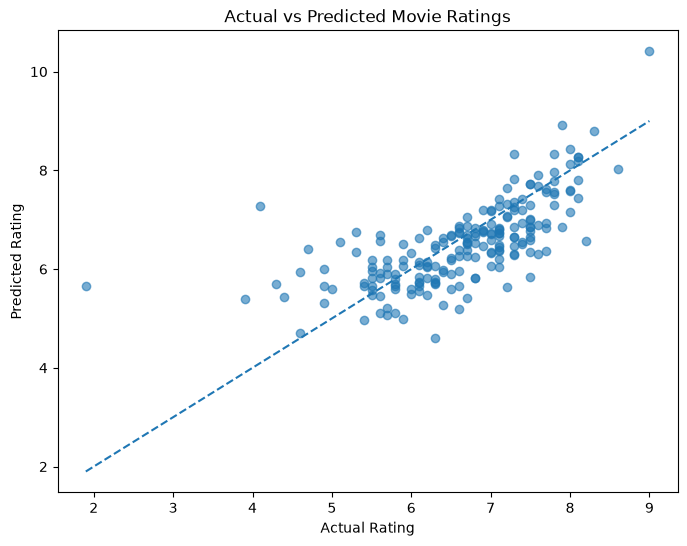

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

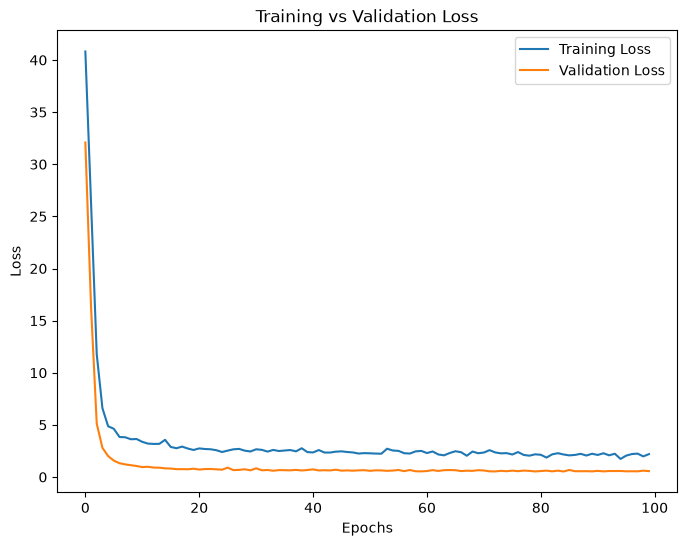

In [12]:
plt.figure(figsize=(8, 6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [13]:
model.save("../model/movie_rating_ann.keras")

print("Model saved successfully!")

Model saved successfully!


In [14]:
import joblib

joblib.dump(scaler, "../model/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [15]:
joblib.dump(mlb, "../model/genre_encoder.pkl")

print("Genre encoder saved successfully!")

Genre encoder saved successfully!


In [16]:
def predict_rating(genre, year, runtime, votes, revenue, metascore):

    # Encode genre
    genre_list = [g.strip() for g in genre.split(',')]
    genre_encoded = mlb.transform([genre_list])

    # Create input data
    input_data = pd.DataFrame(
        [[year, runtime, votes, revenue, metascore]],
        columns=[
            'Year',
            'Runtime (Minutes)',
            'Votes',
            'Revenue (Millions)',
            'Metascore'
        ]
    )

    # Combine numerical features + genre features
    input_data = pd.concat(
        [input_data.reset_index(drop=True),
         pd.DataFrame(genre_encoded, columns=mlb.classes_)],
        axis=1
    )

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = model.predict(input_scaled, verbose=0)[0][0]

    return prediction

In [17]:
predicted_rating = predict_rating(
    genre="Action, Adventure",
    year=2020,
    runtime=120,
    votes=100000,
    revenue=50,
    metascore=70
)

print("Predicted Movie Rating:", round(predicted_rating, 2))

Predicted Movie Rating: 6.8
